# NeuralGCM forecast reproduction (deterministic 2.8°)

Reproduces the official [NeuralGCM](https://github.com/google-research/neuralgcm) forecasting quick start from the Nature 2024 paper *"Neural general circulation models for weather and climate"* ([Nature](https://www.nature.com/articles/s41586-024-07744-y) · [arXiv 2311.07222](https://arxiv.org/abs/2311.07222) · [docs](https://neuralgcm.readthedocs.io/en/latest/inference_demo.html)).

We load the published **`v1/deterministic_2_8_deg.pkl`** checkpoint, initialize it from ERA5, roll out a 4-day forecast, and compare NeuralGCM against ERA5 — both as maps and as an RMSE-vs-lead-time skill check.

**Kernel:** select **"Python (NeuralGCM 3.11)"** (created by `setup_env.sh`). The checkpoint and ERA5 data are read anonymously from public Google Cloud Storage — no GCP credentials needed, but outbound network access is required.

In [9]:
import os

# The 2.8deg model needs ~16.7 GiB of GPU memory for encode/unroll, so it only
# runs on the card when ~17 GiB+ is free. By default JAX preallocates ~75% of
# GPU memory on first use; we disable that and allocate on demand so a shared
# card isn't blocked up front. If the GPU is busy / too small, force CPU with
# JAX_PLATFORMS=cpu (slower but needs no GPU memory; ~32 GiB host RAM is plenty).
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import gcsfs
import jax
import numpy as np
import pickle
import xarray

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

# Expect a CudaDevice given the devcontainer GPU + jax[cuda12].
print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


## 1. Load the pretrained checkpoint

`v1/deterministic_2_8_deg.pkl` is the coarsest deterministic model from the paper — the default used in the official demo, chosen here for a fast, fully reproducible run.

In [10]:
model_name = 'v1/deterministic_2_8_deg.pkl'

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print('input variables:', model.input_variables)
print('forcing variables:', model.forcing_variables)

input variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
forcing variables: ['sea_ice_cover', 'sea_surface_temperature']


## 2. Load and regrid ERA5 initial conditions

We pull the variables the model needs from the public ARCO-ERA5 zarr for a short window (the demo uses mid-February 2020, within the paper's 2020 test year), then conservatively regrid from ERA5's 0.25° grid to the model's 2.8° grid.

In [11]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(era5_path, chunks=None, storage_options=dict(token='anon'))

demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # process ERA5 every 24 hours

sliced_era5 = (
    full_era5[model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)
eval_era5

<xarray.Dataset> Size: 43MB
Dimensions:                              (level: 37, time: 5, longitude: 128,
                                          latitude: 64)
Coordinates:
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 40B 2020-02-14...
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 6MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 6MB ...
    temperature                          (time, level, longitude, latitude) float32 6MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 6MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 6MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 6MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 6MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 164kB ...
    sea_surface_temperature              (time, longitude, latitude) float32 164kB ...
Attributes:
    last_updated:           2026-06-01 03:27:53.232444+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-05-26

## 3. Encode and roll out a 4-day forecast

`encode` maps the ERA5 inputs to the model's internal state; `unroll` integrates the hybrid ML + dynamical core forward, emitting one frame every `inner_steps` hours.

In [12]:
inner_steps = 24  # hours between saved frames
outer_steps = 4 * 24 // inner_steps  # 4-day forecast
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps  # forecast lead time in hours

inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
rng_key = jax.random.key(42)  # unused for deterministic models, but required
initial_state = model.encode(inputs, input_forcings, rng_key)

# Use persistence of the initial forcings over the rollout.
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)
predictions_ds

<xarray.Dataset> Size: 34MB
Dimensions:                              (time: 4, level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * time                                 (time) int64 32B 0 24 48 72
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 5MB ...
    sim_time                             (time) float32 16B ...
    specific_humidity                    (time, level, longitude, latitude) float32 5MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 5MB ...
    geopotential                         (time, level, longitude, latitude) float32 5MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 5MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 5MB ...
    temperature                          (time, level, longitude, latitude) float32 5MB ...
Attributes:
    longitude_wavenumbers:     64
    total_wavenumbers:         65
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

## 4. Build the ERA5 target trajectory and combine

The matching ERA5 frames serve as ground truth for the comparison.

In [13]:
target_trajectory = model.inputs_from_xarray(
    eval_era5.thin(time=(inner_steps // data_inner_steps)).isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']
combined_ds

<xarray.Dataset> Size: 68MB
Dimensions:                              (model: 2, time: 4, level: 37,
                                          longitude: 128, latitude: 64)
Coordinates:
  * model                                (model) <U9 72B 'ERA5' 'NeuralGCM'
  * time                                 (time) int64 32B 0 24 48 72
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    specific_cloud_liquid_water_content  (model, time, level, longitude, latitude) float32 10MB ...
    sim_time                             (model, time) float32 32B ...
    specific_humidity                    (model, time, level, longitude, latitude) float32 10MB ...
    specific_cloud_ice_water_content     (model, time, level, longitude, latitude) float32 10MB ...
    geopotential                         (model, time, level, longitude, latitude) float32 10MB ...
    u_component_of_wind                  (model, time, level, longitude, latitude) float32 10MB ...
    v_component_of_wind                  (model, time, level, longitude, latitude) float32 10MB ...
    temperature                          (model, time, level, longitude, latitude) float32 10MB ...
Attributes:
    longitude_wavenumbers:     64
    total_wavenumbers:         65
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

## 5. Compare NeuralGCM vs ERA5 (maps)

Each row is a forecast lead time; left column is ERA5, right column is NeuralGCM.

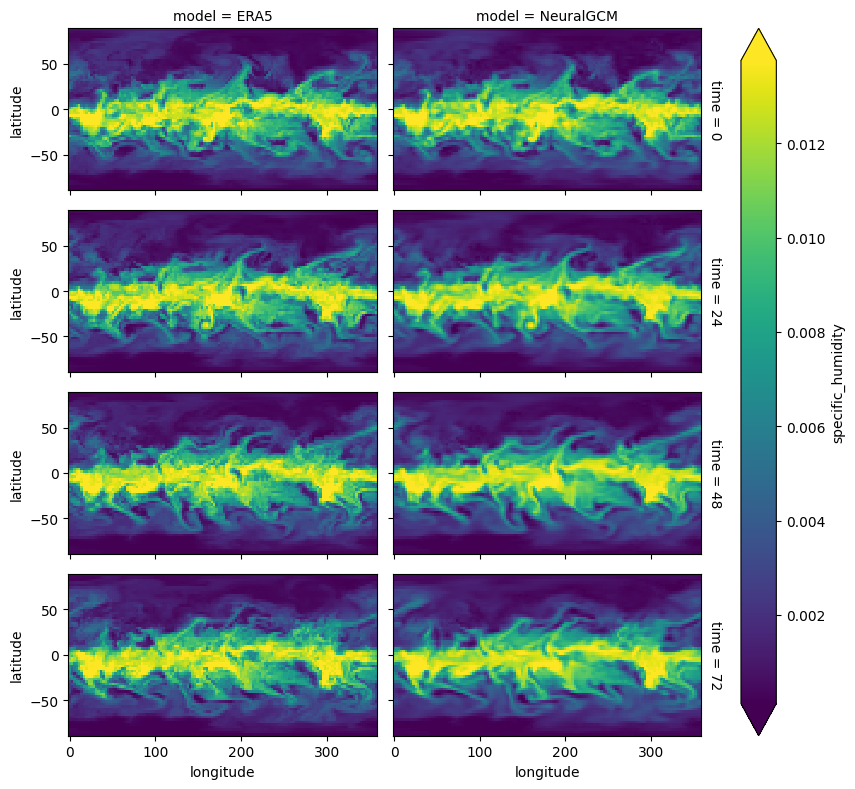

In [14]:
combined_ds.specific_humidity.sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model',
    robust=True, aspect=2, size=2,
);

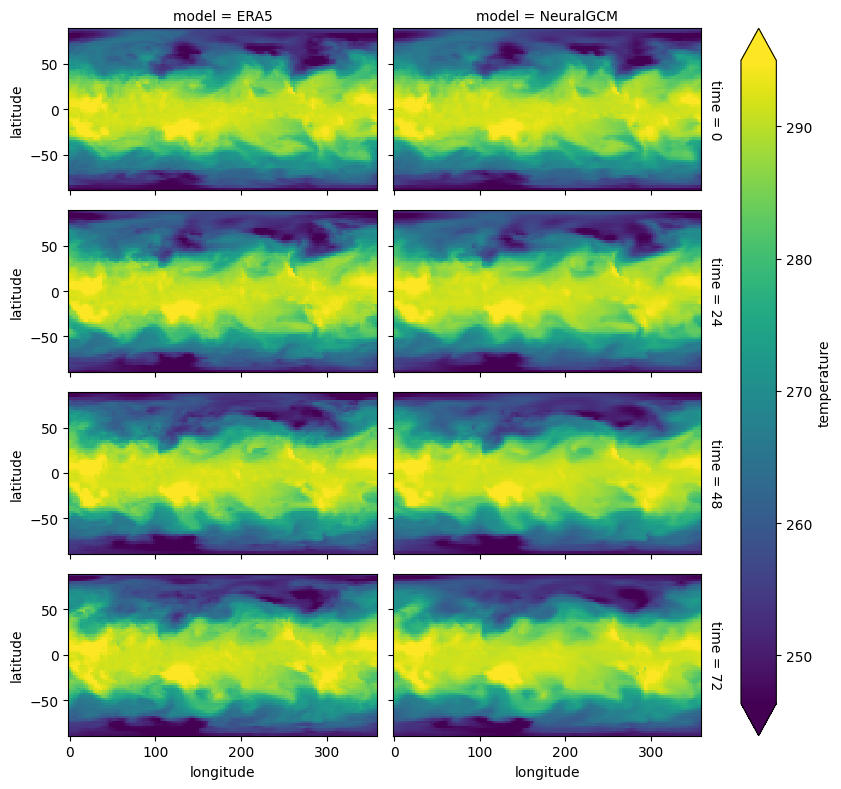

In [15]:
combined_ds.temperature.sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model',
    robust=True, aspect=2, size=2,
);

## 6. Skill check: RMSE vs lead time

A latitude-weighted RMSE between the NeuralGCM forecast and ERA5 at each lead time. Error should grow with lead time — the expected signature of a skillful forecast.

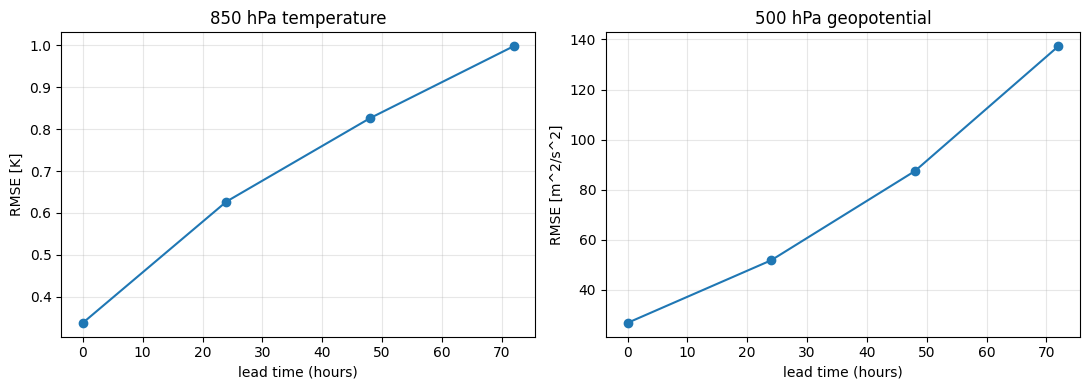

In [16]:
import matplotlib.pyplot as plt

weights = np.cos(np.deg2rad(predictions_ds.latitude))

def weighted_rmse(var, level=None):
    pred = predictions_ds[var]
    truth = target_data_ds[var]
    if level is not None:
        pred = pred.sel(level=level)
        truth = truth.sel(level=level)
    err2 = (pred - truth) ** 2
    return np.sqrt(err2.weighted(weights).mean(['longitude', 'latitude']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

weighted_rmse('temperature', level=850).plot(ax=axes[0], marker='o')
axes[0].set(title='850 hPa temperature', xlabel='lead time (hours)', ylabel='RMSE [K]')

weighted_rmse('geopotential', level=500).plot(ax=axes[1], marker='o')
axes[1].set(title='500 hPa geopotential', xlabel='lead time (hours)', ylabel='RMSE [m^2/s^2]')

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()